In [1]:
# Set gpu to run on 1
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"
import tensorflow as tf
import gc

2025-05-20 11:31:40.643698: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 11:31:40.695613: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 11:31:40.695645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 11:31:40.696906: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-20 11:31:40.706881: I tensorflow/core/platform/cpu_feature_guar

In [2]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
# from detecto import core, utils, visualize
# from detecto.visualize import show_labeled_image, plot_prediction_grid
# from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
# import torch
import tensorflow as tf
from tensorflow.keras.models import load_model

np.random.seed(779)
tf.random.set_seed(779)



In [3]:
batch_size = 4


In [4]:
File_path = '/media/2tbdisk3/data/Haidee/Results/'


In [5]:
prediction_save_path = '/media/2tbdisk3/data/Haidee/Results/Predictions/'

In [6]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

<!-- ## Visualise model training history ## -->

In [7]:
# import pandas as pd

# Run 0 # Base
# run = 'run0'
# history_var3 = pd.read_csv(f'{File_path}/2025-05-18run0_everything_model50px - no_OneHotEncoding_history_var3_subset.csv')

##Run 1 # Each variable split
img_size = 50
run = 'run1'
history_brix = pd.read_csv(f'{File_path}2025-05-19run1_single_feature50_no_one_hot_encodinghistory_brix.csv')
history_starch = pd.read_csv(f'{File_path}2025-05-19run1_single_feature50_no_one_hot_encodinghistory_starch.csv')
history_firmness = pd.read_csv(f'{File_path}2025-05-19run1_single_feature50_no_one_hot_encoding_2025-05-19history_firmness.csv')

# # #Run 2
# # history_brix = pd.read_csv(f'{File_path}2025-04-05run2_single_feature50history_brix.csv')
# # history_starch = pd.read_csv(f'{File_path}2025-04-06run2_single_feature50history_starch.csv')
# # history_firmness = pd.read_csv(f'{File_path}2025-04-06run2_single_feature50_2025-04-06history_firmness.csv')

# #Run 2.1
# history_brix = pd.read_csv(f'{File_path}2025-04-11run2.1_single_feature50_no_one_hot_encodinghistory_brix.csv')
# history_starch = pd.read_csv(f'{File_path}2025-04-11run2.1_single_feature50_no_one_hot_encodinghistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-11run2.1_single_feature50_no_one_hot_encoding_2025-04-11history_firmness.csv')

# # # Run 3
# # history_brix = pd.read_csv(f'{File_path}2025-04-06run3_img_res40history_brix.csv')
# # history_starch = pd.read_csv(f'{File_path}2025-04-06run3_img_res40history_starch.csv')
# # history_firmness = pd.read_csv(f'{File_path}2025-04-06run3_img_res40history_firmness.csv')


# # # Run 4
# history_brix =     pd.read_csv(f'{File_path}2025-04-07run4_img_res20history_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-07run4_img_res20history_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-07run4_img_res20history_firmness.csv')

# # Run 5
# history_brix =     pd.read_csv(f'{File_path}2025-04-08run5_cnn4_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-08run5_cnn4_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-08run5_cnn4_20pxhistory_firmness.csv')

# # # Run 6
# history_brix =     pd.read_csv(f'{File_path}2025-04-08run6_cnn4_40pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-08run6_cnn4_40pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-08run6_cnn4_40pxhistory_firmness.csv')

# # # Run 7
# history_brix =     pd.read_csv(f'{File_path}2025-04-10run7_cnn4_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-10run7_cnn4_20pxhistory_firmness.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-10run7_cnn4_20pxhistory_starch.csv')


# # # # Run 8
# history_brix =     pd.read_csv(f'{File_path}2025-04-10run8_cnn3_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-10run8_cnn3_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-10run8_cnn3_20pxhistory_firmness.csv')

# # Run 9
# history_brix =     pd.read_csv(f'{File_path}2025-04-10run9_cnn6_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-10run9_cnn6_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-10run9_cnn6_20pxhistory_firmness.csv')

# # Run 10
# history_brix =     pd.read_csv(f'{File_path}2025-04-12run10_bays_opt_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-12run10_bays_opt_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-12run10_bays_opt_20pxhistory_firmness.csv')

# # Run 11
# history_brix =     pd.read_csv(f'{File_path}2025-04-13run11_side_a_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-13run11_side_a_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-13run11_side_a_20pxhistory_firmness.csv')


#========= old data below
# # # Run 11 # Did not rerun
# # history_brix =     pd.read_csv(f'{File_path}2025-03-11run11_transformer_50pxhistory_brix.csv')
# # history_starch =   pd.read_csv(f'{File_path}2025-03-11run11_transformer_50pxhistory_starch.csv')
# # history_firmness = pd.read_csv(f'{File_path}2025-03-10run11_transformer_50pxhistory_firmness.csv')

# # Run 12 Split by geographical and temporal
# # history_brix_NZ2023     = pd.read_csv(f'{File_path}2025-03-31run12_res40_NZ2023history_brix.csv')
# # history_starch_NZ2023   = pd.read_csv(f'{File_path}2025-03-31run12_res40_NZ2023history_starch.csv')
# # history_firmness_NZ2023 = pd.read_csv(f'{File_path}2025-03-31run12_res40_NZ2023history_firmness.csv')
# # history_brix_NZ2024     = pd.read_csv(f'{File_path}2025-03-31run12_res40_NZ2024history_brix.csv')
# # history_starch_NZ2024   = pd.read_csv(f'{File_path}2025-03-31run12_res40_NZ2024history_starch.csv')
# # history_firmness_NZ2024 = pd.read_csv(f'{File_path}2025-03-31run12_res40_NZ2024history_firmness.csv')
# # history_brix_UK2024     = pd.read_csv(f'{File_path}2025-03-31run12_res40_UK2024history_brix.csv')
# # history_starch_UK2024   = pd.read_csv(f'{File_path}2025-03-31run12_res40_UK2024history_starch.csv')
# # history_firmness_UK2024 = pd.read_csv(f'{File_path}2025-03-31run12_res40_UK2024history_firmness.csv')

# # Run 13 Split by cultivar
# # history_brix_BB     = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_BBhistory_brix.csv')
# # history_brix_FJ   = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_FJhistory_brix.csv')
# # history_brix_GL = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_GLhistory_brix.csv')
# # history_brix_GD = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_GDhistory_brix.csv')

# # history_firmness_BB     = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_BBhistory_firmness.csv')
# # history_firmness_FJ   = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_FJhistory_firmness.csv')
# # history_firmness_GL = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_GLhistory_firmness.csv')
# # history_firmness_GD = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_GDhistory_firmness.csv')

# # history_starch_BB     = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_BBhistory_starch.csv')
# # history_starch_FJ   = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_FJhistory_starch.csv')
# # history_starch_GL = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_GLhistory_starch.csv')
# # history_starch_GD = pd.read_csv(f'{File_path}2025-03-31run13_img_res_40_GDhistory_starch.csv')

# # Run 14 Bayesian optimisation parameters   
# # history_brix =     pd.read_csv(f'{File_path}2025-04-01run14_img_res_40_bayesian_opthistory_brix.csv')
# # history_starch =   pd.read_csv(f'{File_path}2025-04-01run14_img_res_40_bayesian_opthistory_starch.csv')
# # history_firmness = pd.read_csv(f'{File_path}2025-04-02run14_img_res_40_bayesian_opthistory_firmness.csv')

# # Run 15 side a only
# # history_brix =     pd.read_csv(f'{File_path}2025-04-03run15_side_Ahistory_brix.csv')
# # history_starch =   pd.read_csv(f'{File_path}2025-04-04run15_side_Ahistory_starch.csv')
# # history_firmness = pd.read_csv(f'{File_path}2025-04-04run15_side_Ahistory_firmness.csv')


# # print(history_brix)
# # '/media/2tbdisk1/data/Haidee/Training_results/Feb2025/all_years_results/2025-02-28run4_no_one_hot_encodinghistory_brix.csv'

In [8]:
# Create a function to generate plots

def plot_function(history, feature, value):
    if value == 'loss':
        plt.plot(history['loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title(f'{feature}: Training and Validation Loss Over Epochs')
        plt.legend()
        plt.show()
    elif value == 'MAE':
        plt.plot(history['mae'], label='Train MAE')
        plt.plot(history['val_mae'], label='Validation MAE')
        plt.xlabel('Epochs')
        plt.ylabel('MAE')
        plt.title(f'{feature}:Training and Validation MAE Over Epochs')
        plt.legend()
        plt.show()



In [9]:
# plot_function(history_var3,'All three variables', 'MAE')
# plot_function(history_var3,'All three variables', 'loss')

In [10]:
# 

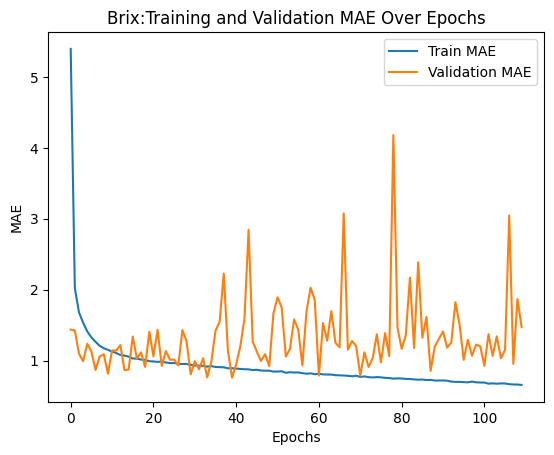

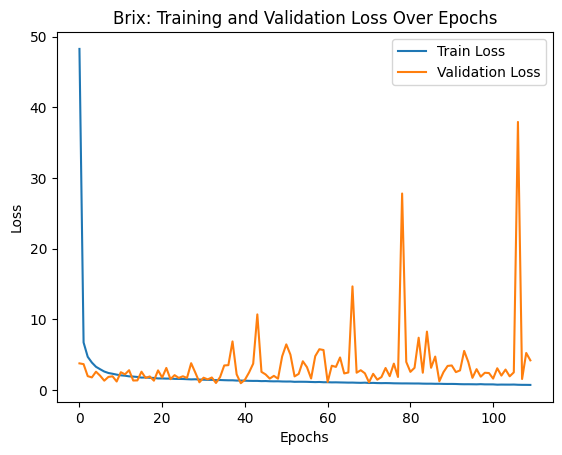

In [11]:
plot_function(history_brix, 'Brix', 'MAE')
plot_function(history_brix, 'Brix', 'loss')

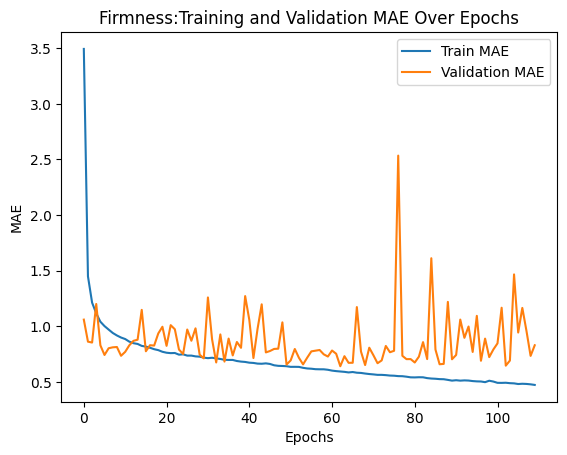

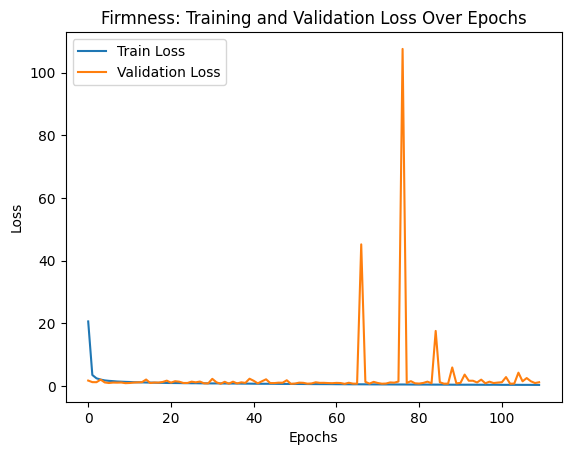

In [12]:
plot_function(history_firmness, 'Firmness', 'MAE')
plot_function(history_firmness, 'Firmness', 'loss')

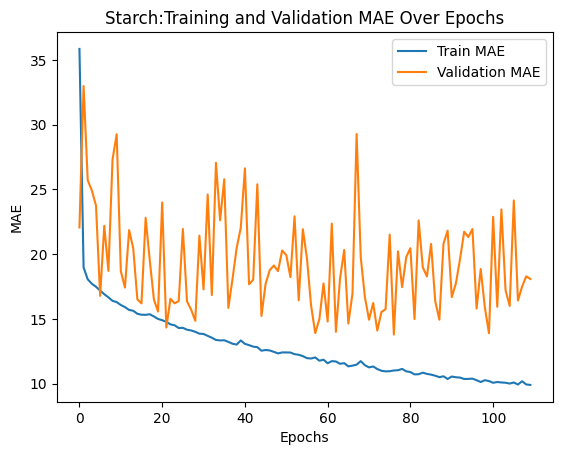

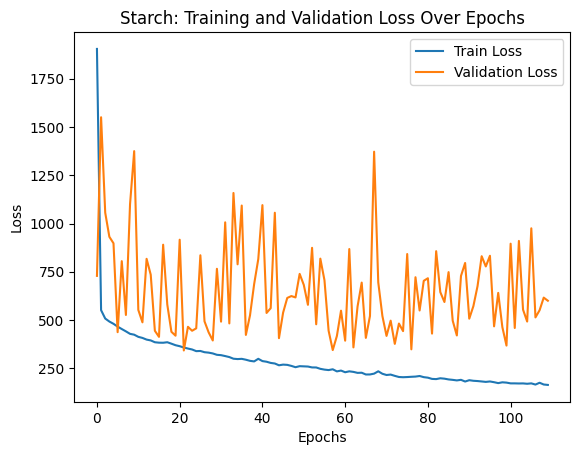

In [13]:
plot_function(history_starch, 'Starch', 'MAE')
plot_function(history_starch, 'Starch', 'loss')

In [14]:
# # load prediction models


## Run 0
# img_size = 50
# run_no = 'run0'
# one_hot_encoding = False
# prediction_model_var3 = tf.keras.models.load_model(f"{File_path}2025-05-18run0_everything_model50px - no_OneHotEncoding_model_file_var3.keras")


#Run1
img_size = 50
run_no = 'run1'
prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-19run1_single_feature50_no_one_hot_encoding_model_file_starch.keras")
prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-19run1_single_feature50_no_one_hot_encoding_model_file_brix.keras")
prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-19run1_single_feature50_no_one_hot_encoding_2025-05-19_model_file_firmness.keras")


# # # Run2
# # img_size = 50
# # run_no = 'run2'
# # prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-06run2_single_feature50_model_file_starch.keras")
# # prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-05run2_single_feature50_model_file_brix.keras")
# # prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-06run2_single_feature50_2025-04-06_model_file_firmness.keras")


# # Run2.1
# img_size = 50
# run_no = 'run2.1'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-11run2.1_single_feature50_no_one_hot_encoding_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-11run2.1_single_feature50_no_one_hot_encoding_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-11run2.1_single_feature50_no_one_hot_encoding_2025-04-11_model_file_firmness.keras")


# # # Run3 
# # img_size = 40
# # run_no = 'run3'
# # prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-06run3_img_res40_model_file_starch.keras")
# # prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-06run3_img_res40_model_file_brix.keras")
# # prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-06run3_img_res40_model_file_firmness.keras")


# # # # Run4
# img_size = 20
# run_no = 'run4'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-07run4_img_res20_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-07run4_img_res20_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-07run4_img_res20_model_file_firmness.keras")

# # # Run 5
# img_size = 20
# run_no = 'run5'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-08run5_cnn4_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-08run5_cnn4_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-08run5_cnn4_20px_model_file_firmness.keras")


# # Run 6
# img_size = 40
# run_no = 'run6'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-08run6_cnn4_40px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-08run6_cnn4_40px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-08run6_cnn4_40px_model_file_firmness.keras")

# # Run 7 
# img_size = 20
# run_no = 'run7'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-10run7_cnn4_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-10run7_cnn4_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-10run7_cnn4_20px_model_file_firmness.keras")


# # Run 8
# img_size = 20
# run_no = 'run8'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-10run8_cnn3_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-10run8_cnn3_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-10run8_cnn3_20px_model_file_firmness.keras")

# # # Run 9
# img_size = 20
# run_no = 'run9'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-10run9_cnn6_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-10run9_cnn6_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-10run9_cnn6_20px_model_file_firmness.keras")

# # # Run 10
# run_no = 'run10'
# img_size = 20
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-12run10_bays_opt_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-12run10_bays_opt_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-12run10_bays_opt_20px_model_file_firmness.keras")

# # Run 11
# run_no = 'run11'
# img_size = 20
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-13run11_side_a_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-13run11_side_a_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-13run11_side_a_20px_model_file_firmness.keras")

# # # Run 11


## ===== old data below

# # # Run 11 # deserialise the unknown PatchEmbedding layer
# # img_size = 50
# # prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-03-11run11_transformer_50px_model_file_starch.keras", custom_objects={"PatchEmbedding": PatchEmbedding})
# # prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-03-11run11_transformer_50px_model_file_brix.keras", custom_objects={"PatchEmbedding": PatchEmbedding})
# # prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-03-10run11_transformer_50px_model_file_firmness.keras", custom_objects={"PatchEmbedding": PatchEmbedding})


# # # # Run 12
# # img_size = 40
# # run_no = 'run12'
# # prediction_model_starch_NZ2023 = tf.keras.models.load_model(f"{File_path}2025-03-11run12_res40_NZ2023_model_file_starch.keras")
# # prediction_model_brix_NZ2023 = tf.keras.models.load_model(f"{File_path}2025-03-11run12_res40_NZ2023_model_file_brix.keras")
# # prediction_model_firmness_NZ2023 = tf.keras.models.load_model(f"{File_path}2025-03-11run12_res40_NZ2023_model_file_firmness.keras")
# # prediction_model_starch_NZ2024 = tf.keras.models.load_model(f"{File_path}2025-03-11run12_res40_NZ2024_model_file_starch.keras")
# # prediction_model_brix_NZ2024 = tf.keras.models.load_model(f"{File_path}2025-03-11run12_res40_NZ2024_model_file_brix.keras")
# # prediction_model_firmness_NZ2024 = tf.keras.models.load_model(f"{File_path}2025-03-11run12_res40_NZ2024_model_file_firmness.keras")

# # # # # Run 13
# # img_size = 40
# # run_no = 'run13'
# # prediction_model_BB_brix        = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_BB_model_file_brix.keras')
# # prediction_model_FJ_brix        = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_FJ_model_file_brix.keras')
# # prediction_model_GD_brix        = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_GD_model_file_brix.keras')
# # prediction_model_GL_brix        = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_GL_model_file_brix.keras')
# # prediction_model_BB_firmness    = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_BB_model_file_firmness.keras')
# # prediction_model_FJ_firmness    = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_FJ_model_file_firmness.keras')
# # prediction_model_GD_firmness    = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_GD_model_file_firmness.keras')
# # prediction_model_GL_firmness    = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_GL_model_file_firmness.keras')
# # prediction_model_BB_starch      = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_BB_model_file_starch.keras')
# # prediction_model_FJ_starch      = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_FJ_model_file_starch.keras')
# # prediction_model_GD_starch      = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_GD_model_file_starch.keras')
# # prediction_model_GL_starch      = tf.keras.models.load_model(f'{File_path}2025-03-31run13_img_res_40_GL_model_file_starch.keras')


# # Run 14
# # run_no = 'run14'
# # img_size = 40
# # prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-01run14_img_res_40_bayesian_opt_model_file_starch.keras")
# # prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-01run14_img_res_40_bayesian_opt_model_file_brix.keras")
# # prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-02run14_img_res_40_bayesian_opt_model_file_firmness.keras")


# # # Run 15
# # run_no = 'run15'
# # img_size = 40
# # prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-04run15_side_A_model_file_starch.keras")
# # prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-03run15_side_A_model_file_brix.keras")
# # prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-04run15_side_A_model_file_firmness.keras")



2025-05-20 11:31:45.068597: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 888 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2025-05-20 11:31:45.071768: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13682 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


In [15]:
if img_size == 30 or img_size == 20:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'



# #Train data


X_train_Firmness_train          = np.load(f'{training_data_save_path}X_train_all_years_Firmness_shuffled.npy')
Y_train_Firmness_train          = np.load(f'{training_data_save_path}Y_train_all_years_Firmness_shuffled.npy')
Firmness_encoder_shuffled  = np.load(f'{training_data_save_path}X_train_all_years_Firmness_encoder_shuffled.npy')
X_train_Brix_train          = np.load(f'{training_data_save_path}X_train_all_years_Brix_shuffled.npy')
Y_train_Brix_train          = np.load(f'{training_data_save_path}Y_train_all_years_Brix_shuffled.npy')
Brix_encoder_shuffled  = np.load(f'{training_data_save_path}X_train_all_years_Brix_encoder_shuffled.npy')
X_train_Starch_train          = np.load(f'{training_data_save_path}X_train_all_years_Starch_shuffled.npy')
Y_train_Starch_train          = np.load(f'{training_data_save_path}Y_train_all_years_Starch_shuffled.npy')
Starch_encoder_shuffled  = np.load(f'{training_data_save_path}X_train_all_years_Starch_encoder_shuffled.npy')


# Test data
Y_test_all_years_Starch_shuffled = np.load(f'{training_data_save_path}Y_test_all_years_Starch_shuffled.npy')
X_test_all_years_Starch_shuffled = np.load(f'{training_data_save_path}X_test_all_years_Starch_shuffled.npy')
X_test_all_years_Starch_encoder = np.load(f'{training_data_save_path}X_test_all_years_Starch_encoder_shuffled.npy')
Y_test_all_years_Brix_shuffled = np.load(f'{training_data_save_path}Y_test_all_years_Brix_shuffled.npy')
X_test_all_years_Brix_shuffled = np.load(f'{training_data_save_path}X_test_all_years_Brix_shuffled.npy')
X_test_all_years_Brix_encoder = np.load(f'{training_data_save_path}X_test_all_years_Brix_encoder_shuffled.npy')
Y_test_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}Y_test_all_years_Firmness_shuffled.npy')
X_test_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}X_test_all_years_Firmness_shuffled.npy')
X_test_all_years_Firmness_encoder = np.load(f'{training_data_save_path}X_test_all_years_Firmness_encoder_shuffled.npy')

In [16]:
# print(Y_train_Starch_train.dtype)

In [ ]:
def prep_data(file_list, cultivars, img_size, batch_size, prediction_model, hotencoding=True):

    # Initialize lists to store the batch data
    batch_data = []
    batch_cultivars = []

    prediction_model = prediction_model

    # Load the batch of data from file paths
    for i, file in enumerate(file_list):
        try:
            data = np.load(file)
            if img_size == 40 or img_size == 20:
                data_reduced = data[5:-5, 5:-5, :]
                batch_data.append(data_reduced)
            else:
                batch_data.append(data)
            batch_cultivars.append(cultivars[i])
        except FileNotFoundError:
            print(f"File not found: {file}. Skipping...")
            continue

    # Convert lists to numpy arrays
    batch_data = np.array(batch_data)  # Shape: (batch_size, img_size, img_size, 204)
    batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)

    if hotencoding == True:

        if len(batch_data) > 0:
            # Expand cultivar information to match the input data's spatial dimensions
            expanded_cultivars = np.repeat(batch_cultivars[:, np.newaxis, np.newaxis, :], img_size, axis=1)
            expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

            # Concatenate cultivar information with the original data along the last axis
            combined_data = np.concatenate([batch_data, expanded_cultivars], axis=-1)  # Shape: (batch_size, img_size, img_size, 210)
    else:
        combined_data = batch_data

    # Use the combined data for predictions
    predictions = prediction_model.predict(combined_data)

    # # Convert NumPy array to TensorFlow tensor and move it to GPU
    # combined_data = tf.convert_to_tensor(combined_data, dtype=tf.float32)

    # # Run prediction on GPU
    # predictions = prediction_model(combined_data, training=False)
    # tf.print(predictions)

    return predictions

In [18]:
print(X_test_all_years_Starch_shuffled[:3])
print(X_test_all_years_Starch_encoder[:3])


['50px/UK2024/50px_Braeburn_943_15549.npy'
 '50px/UK2024/50px_Braeburn_1468_13456.npy'
 '50px/NZ2023/50px_Fuji_170_3467.npy']
[[1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]


In [19]:
# print(prediction_model_brix.summary())
# print(prediction_model_firmness.summary())

In [20]:
# print(prediction_model_starch.summary())

In [21]:
# # for var 3 data
# import numpy as np

# def prep_data(file_list, cultivars, img_size, batch_size, prediction_model):
#     # Initialize lists to store the batch data
#     batch_data = []
#     batch_cultivars = []

#     # Load the batch of data from file paths
#     for i, file in enumerate(file_list):
#         try:
#             data = np.load(file)
#             if img_size == 14:
#                 data_reduced = data[3:-3, 3:-3, :]
#             elif img_size == 40:
#                 data_reduced = data[5:-5, 5:-5, :]
#             else:
#                 data_reduced = data

#             batch_data.append(data_reduced)
#             batch_cultivars.append(cultivars[i])

#             # Process in smaller batches
#             if (i + 1) % batch_size == 0 or (i + 1) == len(file_list):
#                 # Convert lists to numpy arrays
#                 batch_data_np = np.array(batch_data, dtype=np.float32)
#                 batch_cultivars_np = np.array(batch_cultivars, dtype=np.float32)

#                 # Expand cultivar information to match the input data's spatial dimensions
#                 expanded_cultivars = np.repeat(batch_cultivars_np[:, np.newaxis, np.newaxis, :], img_size, axis=1)
#                 expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

#                 # Concatenate cultivar information with the original data along the last axis
#                 combined_data = np.concatenate([batch_data_np, expanded_cultivars], axis=-1)

#                 # Use the combined data for predictions
#                 predictions = prediction_model.predict(combined_data)

#                 # Clear batch data to free up memory
#                 batch_data = []
#                 batch_cultivars = []

#                 # Return predictions for the current batch
#                 yield predictions

#         except FileNotFoundError:
#             print(f"File not found: {file}. Skipping...")
#             continue

# # Example usage
# # predictions = list(prep_data(file_list, cultivars, img_size, batch_size, prediction_model))


In [22]:
# plot the predictions against the actual values

# Create a function to generate predicted vs actual plots
from sklearn.metrics import r2_score

def evaluation_plot(Actual, Predicted, Name):
     Actual = Actual.values.flatten()
     Predicted = Predicted.values.flatten()
     plt.scatter(Actual, Predicted, alpha = 0.5)
     m, b = np.polyfit(Actual, Predicted, 1)
     plt.plot(Actual, m*Actual + b, label='Best Fit Line', color = "black")
     min_val = min(min(Actual), min(Predicted))
     max_val = max(max(Actual), max(Predicted))
     plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Actual = Predicted')
     plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=True, fontsize = 'x-small')
     r2 = r2_score(Actual, Predicted)
     rmse_res = rmse(Actual, Predicted)
     plt.text(0.95, 0.05, f"R² = {r2:.3f}\nRMSE = {rmse_res:.3f}", 
             transform=plt.gca().transAxes, fontsize=12, color="darkgreen",
             verticalalignment='bottom', horizontalalignment='right')
     plt.xlabel('Actual')
     plt.ylabel('Predicted')
     plt.title(f'{Name} - {img_size}px: Predicted vs Actual results')
     plt.show()




In [23]:
def process_predictions(X_train, Y_train, X_test, Y_test, encoder_train, encoder_test, img_size, batch_size, prediction_model, hotencoding=True):
    # Training predictions
    train_predictions = prep_data(X_train, encoder_train, img_size, batch_size, prediction_model=prediction_model)
    train_predictions_df = pd.DataFrame(train_predictions, columns=["Starch"])
    Actual_train = pd.DataFrame(Y_train)
    Predicted_train = train_predictions_df

    # Test predictions
    predictions_brix = prep_data(X_test, encoder_test, img_size, batch_size, prediction_model=prediction_model)
    image_predictions_df = pd.DataFrame(predictions_brix, columns=["Starch"])
    Actual = pd.DataFrame(Y_test)
    Predicted = image_predictions_df

    return Actual_train, Predicted_train, Actual, Predicted



In [24]:
# # for all 3 vars
# import pandas as pd

# def process_predictions(X_train, Y_train, X_test, Y_test, encoder_train, encoder_test, img_size, batch_size, prediction_model):
#     vars = ["Brix", "Avg_firmness", "Starch"]
    
#     # Training predictions
#     train_predictions_df = []
#     train_predictions = list(prep_data(X_train, encoder_train, img_size, batch_size, prediction_model=prediction_model))
#     if train_predictions:
#         train_predictions_df = pd.concat([pd.DataFrame(pred) for pred in train_predictions], ignore_index=True)
#     Actual_train = pd.DataFrame(Y_train)
#     Predicted_train = train_predictions_df

#     # Test predictions
#     image_predictions_df = []
#     predictions_brix = list(prep_data(X_test, encoder_test, img_size, batch_size, prediction_model=prediction_model))
#     if predictions_brix:
#         image_predictions_df = pd.concat([pd.DataFrame(pred) for pred in predictions_brix], ignore_index=True)
#     Actual = pd.DataFrame(Y_test)
#     Predicted = image_predictions_df

#     return Actual_train, Predicted_train, Actual, Predicted



In [25]:
# # For 3 var
# if img_size == 30 or img_size == 20:
#     training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
# elif img_size == 50 or img_size ==40:
#     training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'


# # For multi variable data
# var3 = 'all_3_variables/'

# X_train_var3_train          = np.load(f'{training_data_save_path}{var3}X_train_all_years_var3_shuffled.npy')
# Y_train_var3_train          = np.load(f'{training_data_save_path}{var3}Y_train_all_years_var3_shuffled.npy')
# var3_encoder_shuffled  = np.load(f'{training_data_save_path}{var3}X_train_all_years_var3_encoder_shuffled.npy')

# # Test data
# Y_test_all_years_var3_shuffled = np.load(f'{training_data_save_path}{var3}Y_test_all_years_var3_shuffled.npy')
# X_test_all_years_var3_shuffled = np.load(f'{training_data_save_path}{var3}X_test_all_years_var3_shuffled.npy')
# X_test_all_years_var3_encoder = np.load(f'{training_data_save_path}{var3}X_test_all_years_var3_encoder_shuffled.npy')

# # for all vars
# spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'

# X_train_all_years_var3_shuffled = [spectral_path + file for file in X_train_var3_train]
# X_test_all_years_var3_shuffled = [spectral_path + file for file in X_test_all_years_var3_shuffled]


# # Order is Brix, firmness, starch  Y_train_var3_train
# # print(X_train_all_years_var3_shuffled[:3])



In [26]:
# # var3 - no one hot encoding

# def prep_data(file_list, batch_size, img_size, prediction_model):
#     num_samples = len(file_list)
#     missing_files = []  # List of missing files
#     all_predictions = []  
#     while True:  # Infinite loop for generator
#         for offset in range(0, num_samples, batch_size):
#             # Load the batch of data from file paths
#             batch_files = file_list[offset: offset + batch_size]
#             batch_data = []
            
#             # File loading and handling - ensures model runs if file not found
#             for i, file in enumerate(batch_files):
#                 try:
#                     data = np.load(file)
#                     # print(data.shape)
#                     if img_size == 14:
#                         data_reduced = data[3:-3, 3:-3, :] # Remove 3 pixels from each edge
#                         batch_data.append(data_reduced)
#                     elif img_size == 40:
#                         data_reduced = data[5:-5, 5:-5, :] # Remove 5 pixels from each edge
#                         batch_data.append(data_reduced)
#                     else:                    
#                         batch_data.append(data)
#                 except FileNotFoundError:
#                     missing_files.append(file)
#                     print(f"File not found: {file}. Skipping...")
#                     continue
            
#             # Convert lists to numpy arrays
#             batch_data = np.array(batch_data)  # Shape: (batch_size, 20, 20, 204)
#             # print(batch_data.shape)

#             predictions = prediction_model.predict(batch_data)
#             all_predictions.append(predictions)

#              # Clear batch data to free up memory
#             batch_data = []

#         all_predictions = np.concatenate(all_predictions, axis=0)
#         return all_predictions
        
#         X_train_test, batch_size, img_size, prediction_model_var3

# # for all 3 vars - no one hot encoding
# import pandas as pd

# def process_predictions(X_train, Y_train, X_test, Y_test, img_size, batch_size, prediction_model):
#     vars = ["Brix", "Avg_firmness", "Starch"]
    
#     # Training predictions
#     train_predictions_df = []
#     train_predictions = list(prep_data(X_train, batch_size, img_size, prediction_model=prediction_model))
#     if train_predictions:
#         train_predictions_df = pd.DataFrame(train_predictions, columns= vars)
#     Actual_train = pd.DataFrame(Y_train, columns= vars)
#     Predicted_train = train_predictions_df

#     # Test predictions
#     image_predictions_df = []
#     predictions_brix = list(prep_data(X_test, batch_size, img_size, prediction_model=prediction_model))
#     if predictions_brix:
#         image_predictions_df = pd.DataFrame(predictions_brix, columns= vars)
#     Actual = pd.DataFrame(Y_test, columns= vars)
#     Predicted = image_predictions_df

#     return Actual_train, Predicted_train, Actual, Predicted



# Actual_var3_train, Predicted_var3_train, Actual_var3, Predicted_var3 = process_predictions(
#     X_train_all_years_var3_shuffled, Y_train_var3_train, X_test_all_years_var3_shuffled, Y_test_all_years_var3_shuffled, img_size, batch_size, prediction_model_var3
# )



In [27]:
# print(len(Predicted_var3_train))

In [28]:
# # 3 var
# import pandas as pd

# # Change column names

# Actual_var3_train = pd.DataFrame(Actual_var3_train)
# Actual_var3_train.columns = ["Brix", "Firmness", "Starch"]
# Predicted_var3_train = pd.DataFrame(Predicted_var3_train)
# Predicted_var3_train.columns = ["Brix", "Firmness", "Starch"]
# Actual_var3 = pd.DataFrame(Actual_var3)
# Actual_var3.columns = ["Brix", "Firmness", "Starch"]
# Predicted_var3 = pd.DataFrame(Predicted_var3)
# Predicted_var3.columns = ["Brix", "Firmness", "Starch"]



In [29]:
# print(Predicted_var3)

In [30]:
# Actual_var3_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_var3_var3_train.pkl')
# Predicted_var3_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_var3_var3_train.pkl')
# Actual_var3.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_var3_var3.pkl')
# Predicted_var3.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_var3_var3.pkl')



In [31]:
# print((Predicted_var3_train))

In [32]:
# evaluation_plot(Actual_var3_train['Brix'], Predicted_var3_train['Brix'], 'var3 model predicting brix train')
# evaluation_plot(Actual_var3['Brix'], Predicted_var3['Brix'], 'var3 model predicting brix test')

# evaluation_plot(Actual_var3_train['Firmness'], Predicted_var3_train['Firmness'], 'var3 model predicting firmness train')
# evaluation_plot(Actual_var3['Firmness'], Predicted_var3['Firmness'], 'var3 model predicting firmness test')

# evaluation_plot(Actual_var3_train['Starch'], Predicted_var3_train['Starch'], 'var3 model predicting starch train')
# evaluation_plot(Actual_var3['Starch'], Predicted_var3['Starch'], 'var3 model predicting starch test')

In [33]:
# print(Y_train_var3_train)

In [34]:
# # Data split by cultivar
# if img_size == 20 or img_size == 14:
#     training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_Feb2025/'
# elif img_size == 50 or img_size == 40:  
#     training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_50px/'
    
# # BB brix
# X_train_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_validate_all_years_Brix_shuffled.npy')

# #FJ brix
# X_train_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_validate_all_years_Brix_shuffled.npy')

# # GL brix
# X_train_brix_GL       = np.load(f'{training_data_path}all_years/Gala_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_GL       = np.load(f'{training_data_path}all_years/Gala_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_GL       = np.load(f'{training_data_path}all_years/Gala_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_GL       = np.load(f'{training_data_path}all_years/Gala_Y_validate_all_years_Brix_shuffled.npy')

# #GD brix
# X_train_brix_GD       = np.load(f'{training_data_path}all_years/GD_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_GD       = np.load(f'{training_data_path}all_years/GD_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_GD       = np.load(f'{training_data_path}all_years/GD_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_GD       = np.load(f'{training_data_path}all_years/GD_Y_validate_all_years_Brix_shuffled.npy')


# # BB firmness
# X_train_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_validate_all_years_Brix_shuffled.npy')

# #FJ firmness
# X_train_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_validate_all_years_Brix_shuffled.npy')

# # GL firmness
# X_train_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_Y_validate_all_years_Brix_shuffled.npy')

# #GD firmness
# X_train_firmness_GD       = np.load(f'{training_data_path}all_years/GD_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_GD       = np.load(f'{training_data_path}all_years/GD_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_GD       = np.load(f'{training_data_path}all_years/GD_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_GD       = np.load(f'{training_data_path}all_years/GD_Y_validate_all_years_Brix_shuffled.npy')





# # BB starch
# X_train_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_validate_all_years_Brix_shuffled.npy')

# #FJ starch
# X_train_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_validate_all_years_Brix_shuffled.npy')

# # GL starch
# X_train_starch_GL       = np.load(f'{training_data_path}all_years/Gala_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_GL       = np.load(f'{training_data_path}all_years/Gala_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_GL       = np.load(f'{training_data_path}all_years/Gala_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_GL       = np.load(f'{training_data_path}all_years/Gala_Y_validate_all_years_Brix_shuffled.npy')

# #GD starch
# X_train_starch_GD       = np.load(f'{training_data_path}all_years/GD_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_GD       = np.load(f'{training_data_path}all_years/GD_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_GD       = np.load(f'{training_data_path}all_years/GD_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_GD       = np.load(f'{training_data_path}all_years/GD_Y_validate_all_years_Brix_shuffled.npy')




In [35]:
# print(Y_train_Brix_train[:3])

In [36]:
# # Run for transformer models

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# @keras.saving.register_keras_serializable()
# class PatchEmbedding(layers.Layer):
#     def __init__(self, embed_dim, num_patches, **kwargs):
#         super(PatchEmbedding, self).__init__(**kwargs)
#         self.embed_dim = embed_dim
#         self.num_patches = num_patches
#         self.projection = layers.Dense(embed_dim)
#         self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)

#     def call(self, x):
#         positions = tf.range(start=0, limit=self.num_patches, delta=1)
#         positions = tf.expand_dims(positions, axis=0)
#         embedded_patches = self.projection(x) + self.position_embedding(positions)
#         return embedded_patches

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "embed_dim": self.embed_dim,
#             "num_patches": self.num_patches
#         })
#         return config

#     @classmethod
#     def from_config(cls, config):
#         # Ensure num_patches is provided, otherwise set a default value
#         return cls(
#             embed_dim=config.get("embed_dim", 64),  # Default to 64 if not provided
#             num_patches=config.get("num_patches", 100),  # Default to 100 if not provided
#         )


In [37]:
print(X_test_all_years_Starch_shuffled[:3])


['50px/UK2024/50px_Braeburn_943_15549.npy'
 '50px/UK2024/50px_Braeburn_1468_13456.npy'
 '50px/NZ2023/50px_Fuji_170_3467.npy']


In [38]:
spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'

X_train_all_years_Starch_shuffled = [spectral_path + file for file in X_train_Starch_train]
X_train_all_years_Brix_shuffled = [spectral_path + file for file in X_train_Brix_train]
X_train_all_years_Firmness_shuffled = [spectral_path + file for file in X_train_Firmness_train]

X_test_all_years_Starch_shuffled = [spectral_path + file for file in X_test_all_years_Starch_shuffled]
X_test_all_years_Brix_shuffled = [spectral_path + file for file in X_test_all_years_Brix_shuffled]
X_test_all_years_Firmness_shuffled = [spectral_path + file for file in X_test_all_years_Firmness_shuffled]

print(X_train_all_years_Starch_shuffled[:3])
print(X_test_all_years_Starch_shuffled[:3])

['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Fuji_1423_11860.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Gala_125_9429.npy']
['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/UK2024/50px_Braeburn_943_15549.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/UK2024/50px_Braeburn_1468_13456.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2023/50px_Fuji_170_3467.npy']


<!-- ## Cycle through each X_test (this is each image) and get predictions ## -->

In [39]:
# print(X_test_all_years_Starch_shuffled[:2])
# print(X_test_all_years_Starch_encoder[:2])


In [40]:
# Running transformer model

# @tf.function
# def call(self, x):
#     positions = tf.range(start=0, limit=self.num_patches, delta=1)
#     positions = tf.expand_dims(positions, axis=0)
#     return self.projection(x) + self.position_embedding(positions)


In [41]:
# 

In [42]:
# # Convert data into model input format 20x20x210

# def prep_data(file_list, img_size, batch_size, prediction_model):
#     # missing_files = []  # List of missing files

#     # Initialize lists to store the batch data
#     batch_data = []
#     # batch_cultivars = []

#     prediction_model = prediction_model

#     # Load the batch of data from file paths
#     for i, file in enumerate(file_list):
#         try:
#             data = np.load(file)
#             batch_data.append(data)
#             # batch_cultivars.append(cultivars[i])
#         except FileNotFoundError:
#             # missing_files.append(file)
#             # print(f"File not found: {file}. Skipping...")
#             continue

#     # Convert lists to numpy arrays
#     batch_data = np.array(batch_data)  # Shape: (batch_size, img_size, img_size, 204)
#     # batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)
    

#         # Use the combined data for predictions
#     predictions = prediction_model.predict(batch_data)
#     # print(predictions)

#     return predictions
#     # else:
#     #     print("No data loaded.")
#     #     return None, missing_files


In [43]:
# Test if functions work
# test = prep_data(X_train_all_years_Starch_shuffled[:3], Firmness_encoder_shuffled[:3], img_size, batch_size, prediction_model_firmness, hotencoding=True)
# print(test)

# Actual_starch_train, Predicted_Starch_train, Actual_Starch, Predicted_Starch = process_predictions(
#     X_train_all_years_Starch_shuffled[:3], Y_train_Starch_train[:3], X_test_all_years_Starch_shuffled[:3], Y_test_all_years_Starch_shuffled[:3],
#     Firmness_encoder_shuffled[:3], X_test_all_years_Starch_encoder[:3], img_size, batch_size, prediction_model_starch, hotencoding=False
# )

# print(Predicted_Starch_train)

In [44]:
gc.collect()

289

In [ ]:
# Starch
# # Define your variables



train_predictions = prep_data(X_train_all_years_Starch_shuffled, Firmness_encoder_shuffled, img_size, batch_size, prediction_model = prediction_model_starch)

#no one hot encoding
# train_predictions = prep_data(X_train_all_years_Starch_shuffled, img_size, batch_size, prediction_model = prediction_model_starch)

train_predictions_df = pd.DataFrame(train_predictions, columns = ["Starch"])

Actual_starch_train = pd.DataFrame(Y_train_Starch_train)
Predicted_starch_train = train_predictions_df


predictions_brix = prep_data(X_test_all_years_Starch_shuffled, X_test_all_years_Starch_encoder, img_size, batch_size, prediction_model = prediction_model_starch)

#no one hot encoding
# predictions_brix = prep_data(X_test_all_years_Starch_shuffled, img_size, batch_size, prediction_model = prediction_model_starch)


image_predictions_df = pd.DataFrame(predictions_brix, columns = ["Starch"])

# image_predictions_df.to_csv('image_prediction.csv')

# Starch
Actual_starch = pd.DataFrame(Y_test_all_years_Starch_shuffled)
Predicted_starch = image_predictions_df

# Starch 
# Actual_starch_train, Predicted_Starch_train, Actual_Starch, Predicted_Starch = process_predictions(
#     X_train_all_years_Starch_shuffled, Y_train_Starch_train, X_test_all_years_Starch_shuffled, Y_test_all_years_Starch_shuffled,
#     Firmness_encoder_shuffled, X_test_all_years_Starch_encoder, img_size, batch_size, prediction_model_starch, hotencoding=False
# )

In [ ]:
print(Predicted_Starch)

         Starch
0     51.279945
1     17.306211
2     78.636909
3     81.623985
4     71.221382
...         ...
3863  43.198742
3864  30.915634
3865  31.667860
3866  70.407677
3867  63.354755

[3868 rows x 1 columns]


In [ ]:
Actual_starch_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_starch_train.pkl')
Predicted_Starch_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Starch_train.pkl')
Actual_Starch.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_Starch.pkl')
Predicted_Starch.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Starch.pkl')


In [ ]:
del prediction_model_starch

In [ ]:
# # Run 6, 7 and 8: 2025-03-04 Fuji 976 was a massive outlier 
#     # aggregated_Fuji_976_7551.npy
#     # aggregated_Fuji_976_7549.npy
#     # aggregated_Fuji_976_7550.npy
#     # aggregated_Fuji_976_7552.npy
#     # aggregated_Fuji_976_7553.npy
#     # aggregated_Fuji_976_7554.npy
# print(len(X_train_all_years_Starch_shuffled))
# indices = train_predictions_df[train_predictions_df['Starch']>150].index.tolist()
# print(indices)
# print([X_train_all_years_Starch_shuffled[i] for i in indices])


In [ ]:
# # # Remove outliers

 

# print(len(Predicted_starch_train))
# print(len(Actual_starch_train))

In [ ]:
# print(Outliers_test)

In [ ]:
print(len(Actual_starch_train))
print(len(Predicted_Starch_train))

17610
17610


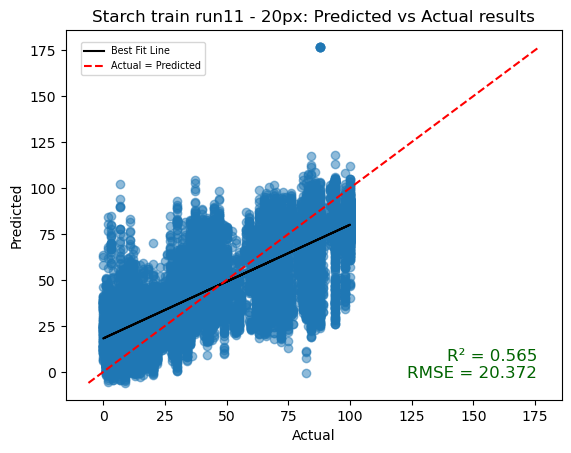

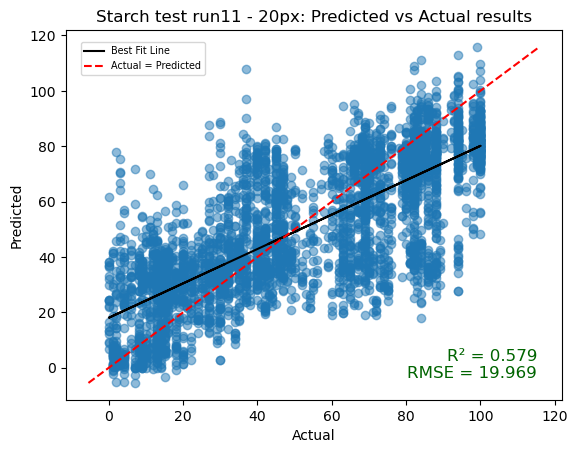

In [ ]:

evaluation_plot(Actual_starch_train, Predicted_Starch_train, f'Starch train {run_no}')

evaluation_plot(Actual_Starch, Predicted_Starch, f'Starch test {run_no}')


In [ ]:
# # # Define your variables



# # train_predictions = prep_data(X_train_all_years_Brix_shuffled, Brix_encoder_shuffled, img_size, batch_size, prediction_model = prediction_model_brix)

# # #no one hot encoding
# # # train_predictions = prep_data(X_train_all_years_Brix_shuffled, img_size, batch_size, prediction_model = prediction_model_brix)

# # train_predictions_df = pd.DataFrame(train_predictions, columns = ["Brix"])

# # Actual_brix_train = pd.DataFrame(Y_train_Brix_train)
# # Predicted_brix_train = train_predictions_df


# # predictions_brix = prep_data(X_test_all_years_Brix_shuffled, X_test_all_years_Brix_encoder, img_size, batch_size, prediction_model = prediction_model_brix)

# # #no one hot encoding
# # # predictions_brix = prep_data(X_test_all_years_Brix_shuffled, img_size, batch_size, prediction_model = prediction_model_brix)


# # image_predictions_df = pd.DataFrame(predictions_brix, columns = ["Brix"])

# # # image_predictions_df.to_csv('image_prediction.csv')

# # # Brix
# # Actual_brix = pd.DataFrame(Y_test_all_years_Brix_shuffled)
# # Predicted_brix = image_predictions_df



# Brix
Actual_brix_train, Predicted_Brix_train, Actual_Brix, Predicted_Brix = process_predictions(
    X_train_all_years_Brix_shuffled, Y_train_Brix_train, X_test_all_years_Brix_shuffled, Y_test_all_years_Brix_shuffled,
    Firmness_encoder_shuffled, X_test_all_years_Brix_encoder, img_size, batch_size, prediction_model_brix
)

121/121 [==============================] - 1s 6ms/step


In [ ]:
del prediction_model_brix

In [ ]:
Actual_brix_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_brix_train.pkl')
Predicted_Brix_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Brix_train.pkl')
Actual_Brix.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_Brix.pkl')
Predicted_Brix.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Brix.pkl')



In [ ]:
import gc
gc.collect()

8113

In [ ]:
# # Run 6 & 7 & 9 & 10: 2025-03-04 Fuji 976 was a massive outlier 
#     # aggregated_Fuji_976_7551.npy
#     # aggregated_Fuji_976_7549.npy
#     # aggregated_Fuji_976_7550.npy
#     # aggregated_Fuji_976_7552.npy
#     # aggregated_Fuji_976_7553.npy
#     # aggregated_Fuji_976_7554.npy
# print(len(X_train_all_years_Brix_shuffled))
# indices = Predicted_brix_train[Predicted_brix_train['Brix']>=35].index.tolist()
# print(indices)
# print([X_train_all_years_Brix_shuffled[i] for i in indices])


In [ ]:
# # # Remove outliers


# # print(len(Predicted_brix_train))
# # print(len(Actual_brix_train))

# # Remove outliers from train_predictions_df and Actual_brix_train
# Predicted_brix_train = Predicted_brix_train[Predicted_brix_train['Brix'] <= 35]
# Actual_brix_train = Actual_brix_train.loc[Predicted_brix_train.index]



# # print(len(Predicted_brix_train))
# # print(len(Actual_brix_train))

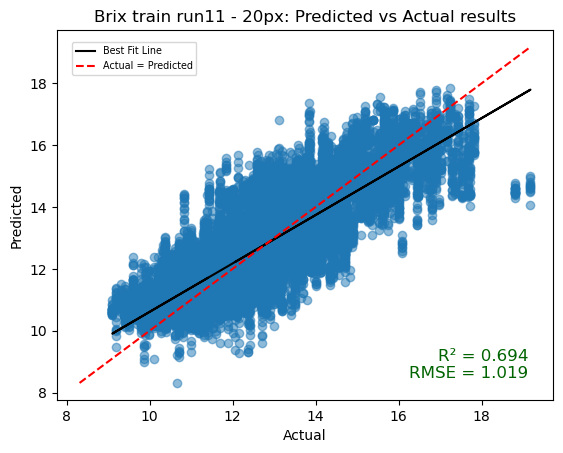

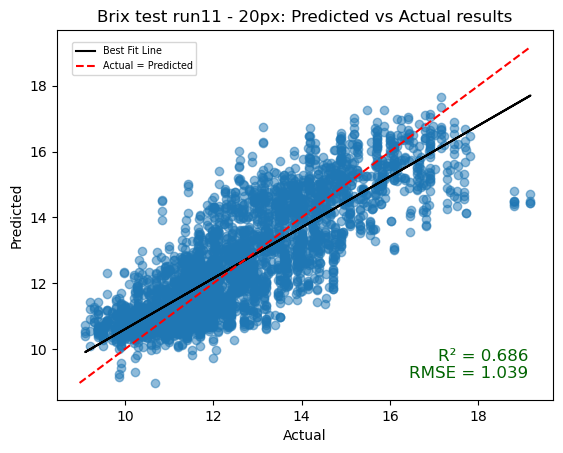

In [ ]:

evaluation_plot(Actual_brix_train, Predicted_Brix_train, f'Brix train {run_no}')

evaluation_plot(Actual_Brix, Predicted_Brix, f'Brix test {run_no}')

In [ ]:
# # Firmness
# # Define your variables



# # train_predictions = prep_data(X_train_all_years_Firmness_shuffled, Firmness_encoder_shuffled, img_size, batch_size, prediction_model = prediction_model_firmness)

# # #no one hot encoding
# # # train_predictions = prep_data(X_train_all_years_Firmness_shuffled, img_size, batch_size, prediction_model = prediction_model_firmness)

# # train_predictions_df = pd.DataFrame(train_predictions, columns = ["Firmness"])

# # Actual_firmness_train = pd.DataFrame(Y_train_Firmness_train)
# # Predicted_firmness_train = train_predictions_df


# # predictions_firmness = prep_data(X_test_all_years_Firmness_shuffled, X_test_all_years_Firmness_encoder, img_size, batch_size, prediction_model = prediction_model_firmness)

# # # no one hot encoding
# # # predictions_firmness = prep_data(X_test_all_years_Firmness_shuffled, img_size, batch_size, prediction_model = prediction_model_firmness)

# # image_predictions_df = pd.DataFrame(predictions_firmness, columns = ["Firmness"])

# # # image_predictions_df.to_csv('image_prediction.csv')

# # # Firmness
# # Actual_firmness = pd.DataFrame(Y_test_all_years_Firmness_shuffled)
# # Predicted_firmness = image_predictions_df

# # Firmness 
Actual_firmness_train, Predicted_Firmness_train, Actual_Firmness, Predicted_Firmness = process_predictions(
    X_train_all_years_Firmness_shuffled, Y_train_Firmness_train, X_test_all_years_Firmness_shuffled, Y_test_all_years_Firmness_shuffled,
    Firmness_encoder_shuffled, X_test_all_years_Firmness_encoder, img_size, batch_size, prediction_model_firmness
)


121/121 [==============================] - 1s 6ms/step


In [ ]:
# # Run 6: 2025-03-04 Fuji 976 was a massive outlier and Jazz 399, 413, 406
#     # aggregated_Fuji_976_7551.npy
#     # aggregated_Fuji_976_7549.npy
#     # aggregated_Fuji_976_7550.npy
#     # aggregated_Fuji_976_7552.npy
#     # aggregated_Fuji_976_7553.npy
#     # aggregated_Fuji_976_7554.npy
# print(len(X_train_all_years_Firmness_shuffled))
# indices = train_predictions_df[train_predictions_df['Firmness'] < -2000].index.tolist()
# print(indices)
# print([X_train_all_years_Firmness_shuffled[i] for i in indices])


In [ ]:
# # Remove outliers


# print(len(train_predictions_df))
# print(len(Actual_firmness_train))

# # Remove outliers from train_predictions_df and Actual_firmness_train
# Predicted_firmness_train = train_predictions_df[train_predictions_df['Firmness'] < 40]
# Actual_firmness_train = Actual_firmness_train.loc[Predicted_firmness_train.index]



# print(len(Predicted_firmness_train))
# print(len(Actual_firmness_train))

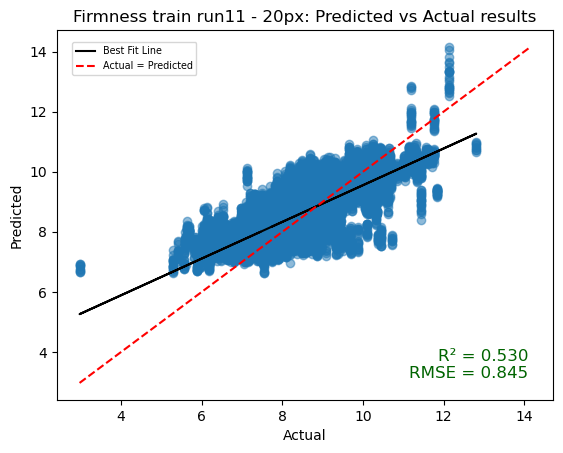

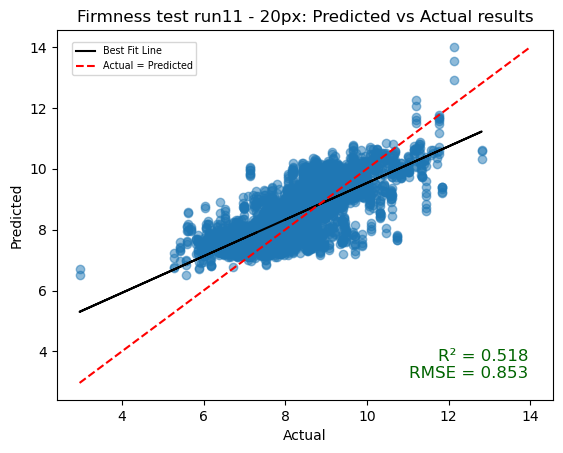

In [ ]:
evaluation_plot(Actual_firmness_train, Predicted_Firmness_train, f'Firmness train {run_no}')

evaluation_plot(Actual_Firmness, Predicted_Firmness, f'Firmness test {run_no}')

In [ ]:
Actual_firmness_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_firmness_train.pkl')
Predicted_Firmness_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Firmness_train.pkl')
Actual_Firmness.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_Firmness.pkl')
Predicted_Firmness.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Firmness.pkl')


In [ ]:
del prediction_model_firmness

<!-- ## View of model architecture -->

In [ ]:
import gc
gc.collect()

0

: 

In [ ]:
# # Try to load the model architecture from model
# import tensorflow as tf
# import keras
# from tensorflow.keras.utils import plot_model


# from tensorflow.keras.models import load_model
# File_path = '/media/2tbdisk1/data/Haidee/Training_results/Feb2025/all_years_results/'
# model = tf.keras.models.load_model(f"{File_path}2025-02-21run1_2025-02-21_model_file_brix.keras")

# model_complex_starch_only = tf.keras.models.clone_model(model)
# # model_complex_starch_only.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])
# model_complex_starch_only.summary()

# # Visualize the model architecture
# plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [ ]:
# 